In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("merged data.csv", parse_dates=["datetime"])
df.set_index("datetime", inplace=True)

# 2. 시계열 기반 파생 피처 생성
df['lag_1'] = df['demand'].shift(1)
df['lag_24'] = df['demand'].shift(24)
df['lag_168'] = df['demand'].shift(168)

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df['rolling_mean_3'] = df['demand'].shift(1).rolling(window=3).mean()
df['rolling_mean_24'] = df['demand'].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df['demand'].shift(1).rolling(window=24).std()

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 4. 결측치 제거
df.dropna(inplace=True)

features = [
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_3', 'rolling_mean_24', 'rolling_std_24',
    'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos',
    'temperature', 'wind_speed', 'precipitation', 'humidity'
]

# 5. 시간 기준 분할: 2025년 이전 vs 2025년 이후
train = df[df.index.year < 2025]
val = df[df.index.year == 2025]

X_train = train.drop(columns=["demand"])
y_train = train["demand"]
X_val = val.drop(columns=["demand"])
y_val = val["demand"]

param_grid = {
    "n_estimators": [7750],
    "max_depth": [7],
    "learning_rate": [0.055]
}

model = XGBRegressor(
    n_estimators=7750,
    max_depth=7,
    learning_rate=0.055,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.055, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=7750,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
model.save_model("best2.json")

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("merged data.csv", parse_dates=["datetime"])
df.set_index("datetime", inplace=True)

# 2. 시계열 기반 파생 피처 생성
df['lag_1'] = df['demand'].shift(1)
df['lag_24'] = df['demand'].shift(24)
df['lag_168'] = df['demand'].shift(168)

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df['rolling_mean_3'] = df['demand'].shift(1).rolling(window=3).mean()
df['rolling_mean_24'] = df['demand'].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df['demand'].shift(1).rolling(window=24).std()

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 4. 결측치 제거
df.dropna(inplace=True)

features = [
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_3', 'rolling_mean_24', 'rolling_std_24',
    'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos',
    'temperature', 'wind_speed', 'precipitation', 'humidity'
]

# 5. 시간 기준 분할: 2025년 이전 vs 2025년 이후
train = df[df.index.year < 2025]
val = df[df.index.year == 2025]

X_train = train.drop(columns=["demand"])
y_train = train["demand"]
X_val = val.drop(columns=["demand"])
y_val = val["demand"]

# 파라미터 후보
# param_grid = {
#     "n_estimators": [100, 300, 500, 800, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000],
#     "max_depth": [3, 4, 5, 6, 7, 8, 9],
#     "learning_rate": [0.01, 0.05, 0.1, 0.3]
# }
# param_grid = {
#     "n_estimators": [6000, 6200, 6400, 6600, 6800, 7000, 7200, 7400, 7600, 7800, 8000],
#     "max_depth": [4,  5, 6, 7, 8],
#     "learning_rate": [0.01, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
# }
# param_grid = {
#     "n_estimators": [7450, 7500, 7550, 7600, 7650, 7700, 7750],
#     "max_depth": [5, 6, 7, 8, 9],
#     "learning_rate": [0.05, 0.055, 0.06, 0.065, 0.07]
# }

param_grid = {
    "n_estimators": [7700, 7725, 7750, 7775, 7800],
    "max_depth": [5, 6, 7, 8, 9],
    "learning_rate": [0.05, 0.055, 0.06]
}

# 모든 조합 생성
param_combinations = list(product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["learning_rate"]
))

best_score = float("inf")
best_model = None
best_params = None

print("총 시도할 조합 개수:", len(param_combinations))

for i, (n_estimators, max_depth, learning_rate) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] 테스트 중: n={n_estimators}, depth={max_depth}, lr={learning_rate}")

    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    print(f"  → MAE={mae:.3f}, RMSE={rmse:.3f}")

    if mae < best_score:  # MAE 기준
        best_score = mae
        best_model = model
        best_params = {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "mae": mae,
            "rmse": rmse
        }

# 최종 결과 출력 및 모델 저장
print("\n가장 좋은 조합:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# 모델 저장
best_model.save_model("best_xgb_demand_model.json")
print("\n모델 저장 완료: best_xgb_demand_model.json")
# # 6. 모델 학습
# model = XGBRegressor(n_estimators=3000, max_depth=7, learning_rate=0.05, random_state=42)
# model.fit(X_train, y_train)

# # 7. 예측 및 평가
# y_pred = model.predict(X_val)
# mae = mean_absolute_error(y_val, y_pred)
# rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# model.save_model("xgb_demand_model.json")

# print(f"Validation MAE (2025년): {mae:.2f}")
# print(f"Validation RMSE (2025년): {rmse:.2f}")


총 시도할 조합 개수: 75

[1/75] 테스트 중: n=7700, depth=5, lr=0.05
  → MAE=5705.195, RMSE=8326.430

[2/75] 테스트 중: n=7700, depth=5, lr=0.055
  → MAE=5755.298, RMSE=8383.653

[3/75] 테스트 중: n=7700, depth=5, lr=0.06
  → MAE=5672.101, RMSE=8282.198

[4/75] 테스트 중: n=7700, depth=6, lr=0.05
  → MAE=5723.570, RMSE=8380.830

[5/75] 테스트 중: n=7700, depth=6, lr=0.055
  → MAE=5735.108, RMSE=8329.721

[6/75] 테스트 중: n=7700, depth=6, lr=0.06
  → MAE=5647.901, RMSE=8318.434

[7/75] 테스트 중: n=7700, depth=7, lr=0.05
  → MAE=5666.304, RMSE=8287.104

[8/75] 테스트 중: n=7700, depth=7, lr=0.055
  → MAE=5738.472, RMSE=8403.217

[9/75] 테스트 중: n=7700, depth=7, lr=0.06
  → MAE=5729.207, RMSE=8387.415

[10/75] 테스트 중: n=7700, depth=8, lr=0.05
  → MAE=5682.483, RMSE=8343.760

[11/75] 테스트 중: n=7700, depth=8, lr=0.055
  → MAE=5635.952, RMSE=8222.729

[12/75] 테스트 중: n=7700, depth=8, lr=0.06
  → MAE=5672.992, RMSE=8346.774

[13/75] 테스트 중: n=7700, depth=9, lr=0.05


KeyboardInterrupt: 

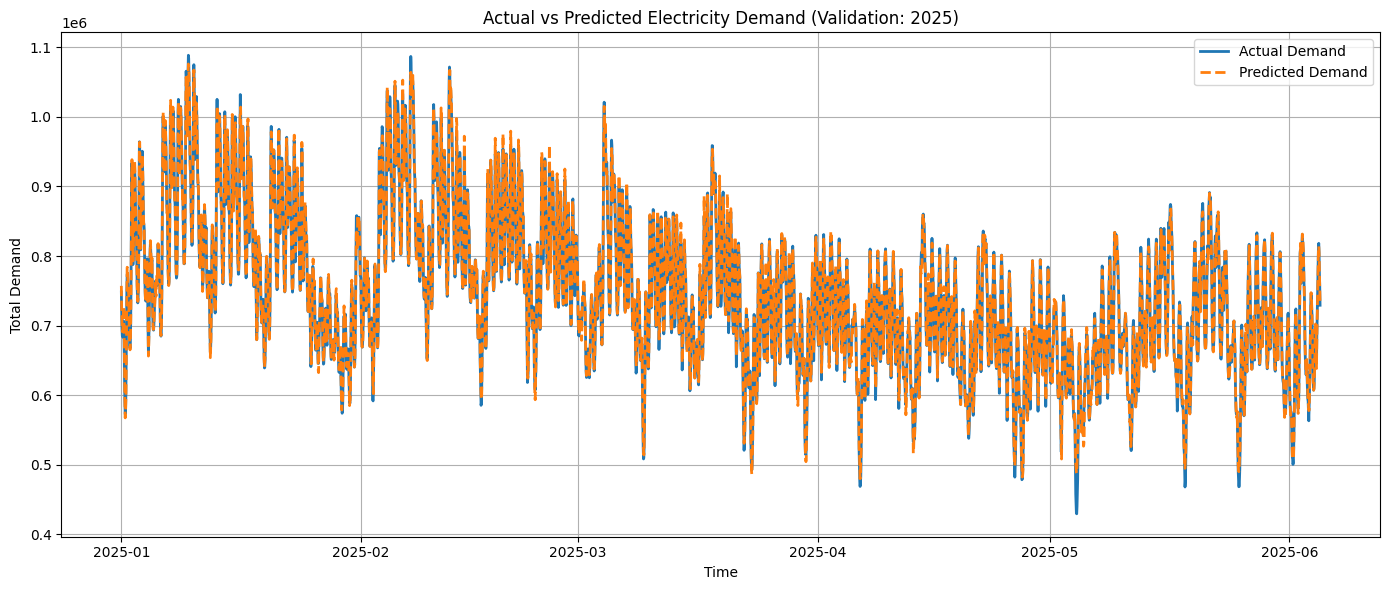

In [12]:
# 8. 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_val.index, y_val, label="Actual Demand", linewidth=2)
plt.plot(y_val.index, y_pred, label="Predicted Demand", linewidth=2, linestyle="--")
plt.title("Actual vs Predicted Electricity Demand (Validation: 2025)")
plt.xlabel("Time")
plt.ylabel("Total Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

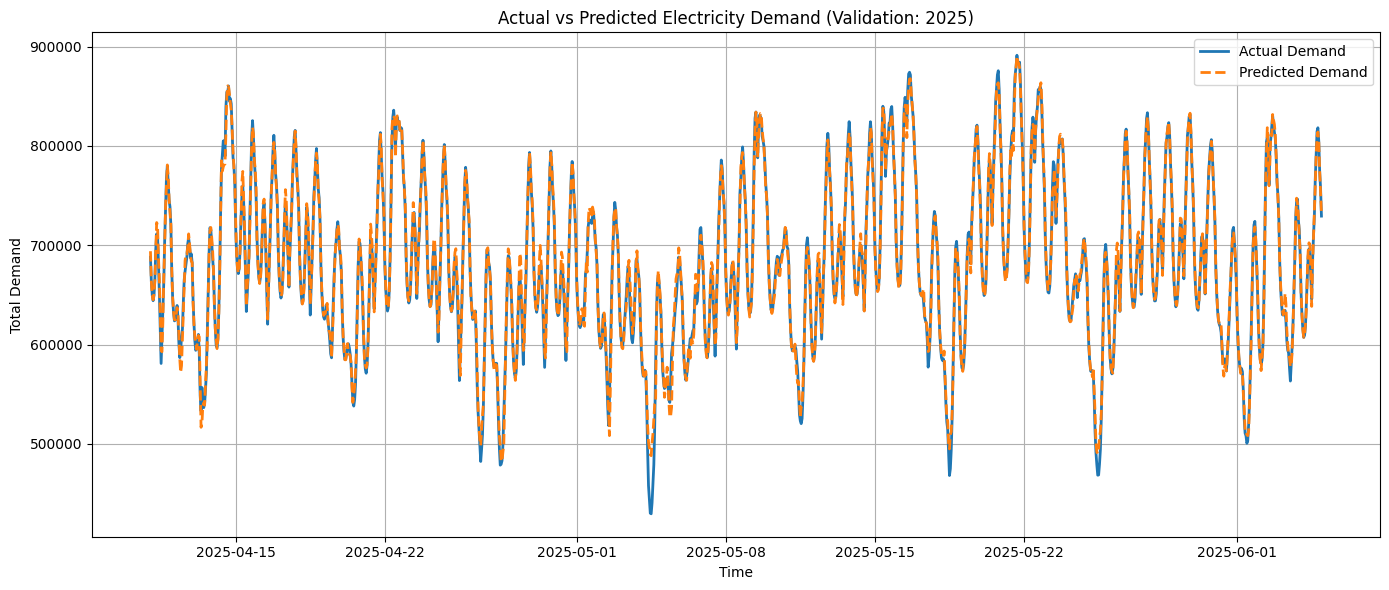

In [13]:
# 8. 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_val.index[24*100:24*180], y_val[24*100:24*180], label="Actual Demand", linewidth=2)
plt.plot(y_val.index[24*100:24*180], y_pred[24*100:24*180], label="Predicted Demand", linewidth=2, linestyle="--")
plt.title("Actual vs Predicted Electricity Demand (Validation: 2025)")
plt.xlabel("Time")
plt.ylabel("Total Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

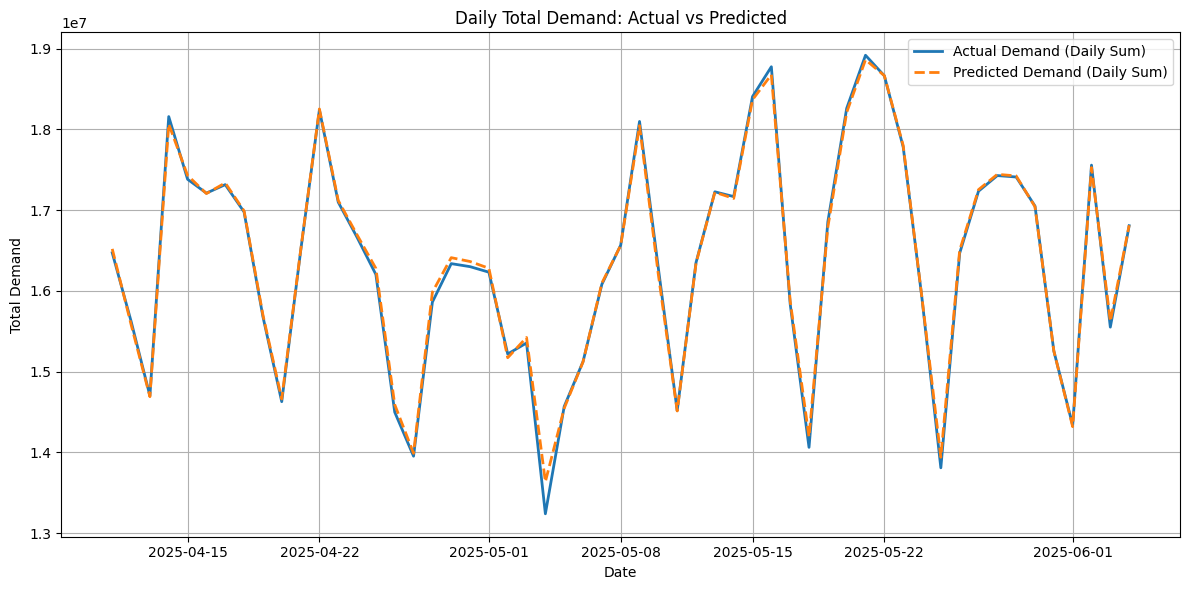

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 시리즈를 데이터프레임으로 변환 (날짜 기준 그룹화 위해)
df_plot = pd.DataFrame({
    "actual": y_val,
    "pred": pd.Series(y_pred, index=y_val.index)  # 예측값에도 인덱스 부여
})

# 2. 날짜 단위로 묶어서 합산
df_plot_daily = df_plot.resample("D").sum()

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_plot_daily.index[100:180], df_plot_daily["actual"][100:180], label="Actual Demand (Daily Sum)", linewidth=2)
plt.plot(df_plot_daily.index[100:180], df_plot_daily["pred"][100:180], label="Predicted Demand (Daily Sum)", linewidth=2, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.title("Daily Total Demand: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZON = 24 * 7          # 7일 = 168시간
features_in_model = model.get_booster().feature_names  # 학습 시 feature 순서

y_pred_recursive = []     # 최종 예측 결과
history = list(y_train[-168:].values)  # lag·rolling 계산용 실제 히스토리

# 검증 구간을 7일 블록 단위로 순회
start = 0
while start < len(X_val):
    end = min(start + HORIZON, len(X_val))
    block_idx = X_val.index[start:end]

    # ---- (1) 1주(168h) 재귀 예측 ----
    for ts in block_idx:
        row = {}

        # ① 시간·주기 피처
        row["hour"] = ts.hour
        row["dayofweek"] = ts.dayofweek
        row["month"] = ts.month
        row["hour_sin"] = np.sin(2 * np.pi * row["hour"] / 24)
        row["hour_cos"] = np.cos(2 * np.pi * row["hour"] / 24)

        # ② 외생 변수: 실제 값 사용
        for f in ["temperature", "wind_speed", "precipitation", "humidity"]:
            row[f] = X_val.loc[ts, f]

        # ③ lag 피처(예측값 포함)
        row["lag_1"]   = history[-1]
        row["lag_24"]  = history[-24]  if len(history) >= 24  else np.nan
        row["lag_168"] = history[-168] if len(history) >= 168 else np.nan

        # ④ rolling 피처
        past = pd.Series(history[-24:])
        row["rolling_mean_3"]  = past[-3:].mean()  if len(past) >= 3  else np.nan
        row["rolling_mean_24"] = past.mean()       if len(past) == 24 else np.nan
        row["rolling_std_24"]  = past.std()        if len(past) == 24 else np.nan

        # ⑤ 결측치가 있으면 예측 불가 → NaN 채우고 넘어감
        if any(pd.isnull(v) for v in row.values()):
            y_pred_recursive.append(np.nan)
            history.append(np.nan)
            continue

        # ⑥ 예측
        row_df = pd.DataFrame([row])[features_in_model]
        pred = model.predict(row_df)[0]

        y_pred_recursive.append(pred)
        history.append(pred)        # 예측값을 히스토리에 추가 (다음 스텝 lag용)

    # ---- (2) 한 블록 예측 끝난 뒤, 실제 값을 히스토리에 덧붙여 drift 방지 ----
    history.extend(y_val[start:end].values)

    start = end  # 다음 7일 블록으로 이동

# ------------------------- 성능 평가 -------------------------
y_pred_series = pd.Series(y_pred_recursive, index=y_val.index)
mask = y_pred_series.notna()
mae  = mean_absolute_error(y_val[mask], y_pred_series[mask])
rmse = np.sqrt(mean_squared_error(y_val[mask], y_pred_series[mask]))

print(f"7-일 단위 재귀 MAE : {mae:.2f}")
print(f"7-일 단위 재귀 RMSE: {rmse:.2f}")

7-일 단위 재귀 MAE : 30450.23
7-일 단위 재귀 RMSE: 46214.59


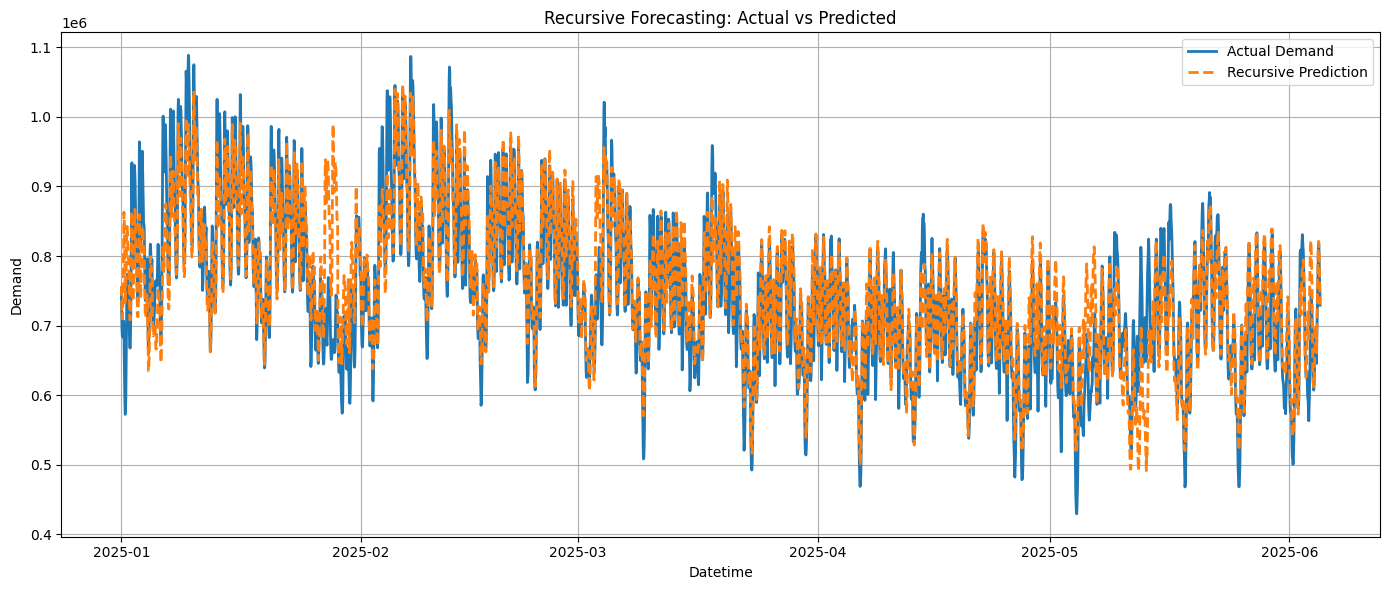

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 예측값 시리즈로 변환 (index를 y_val과 동일하게 설정)
y_pred_series = pd.Series(y_pred_recursive, index=y_val.index)

# 2. 유효한 값만 추출 (NaN이 있는 경우 제외)
valid_idx = y_pred_series.notna()
y_val_valid = y_val[valid_idx]
y_pred_valid = y_pred_series[valid_idx]

# 3. 시각화
plt.figure(figsize=(14, 6))
plt.plot(y_val_valid.index, y_val_valid, label="Actual Demand", linewidth=2)
plt.plot(y_pred_valid.index, y_pred_valid, label="Recursive Prediction", linestyle="--", linewidth=2)
plt.xlabel("Datetime")
plt.ylabel("Demand")
plt.title("Recursive Forecasting: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

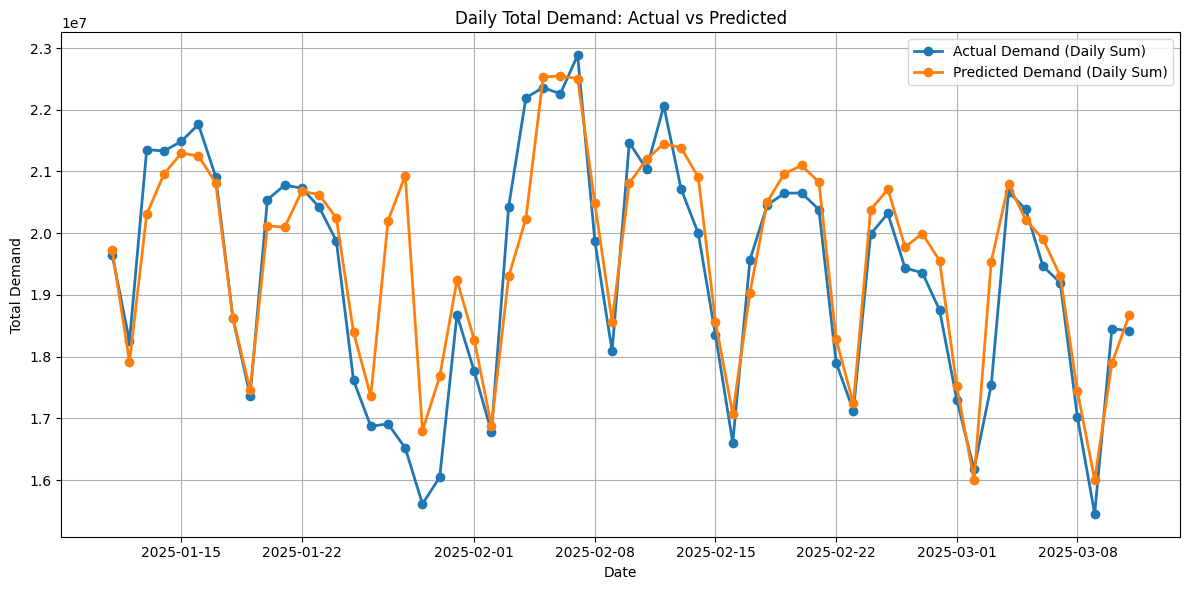

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 시리즈를 데이터프레임으로 변환 (날짜 기준 그룹화 위해)
df_plot = pd.DataFrame({
    "actual": y_val_valid,
    "pred": pd.Series(y_pred_valid, index=y_val_valid.index)  # 예측값에도 인덱스 부여
})

# 2. 날짜 단위로 묶어서 합산
df_plot_daily = df_plot.resample("D").sum()

# 3. 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_plot_daily.index[10:70], df_plot_daily["actual"][10:70], 'o-', label="Actual Demand (Daily Sum)", linewidth=2)
plt.plot(df_plot_daily.index[10:70], df_plot_daily["pred"][10:70], 'o-', label="Predicted Demand (Daily Sum)", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.title("Daily Total Demand: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

100%|===================| 3718/3720 [15:25<00:00]        

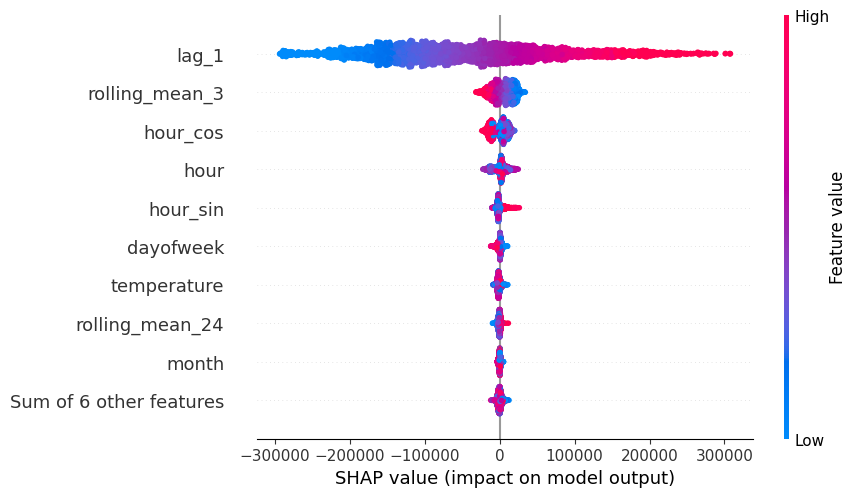

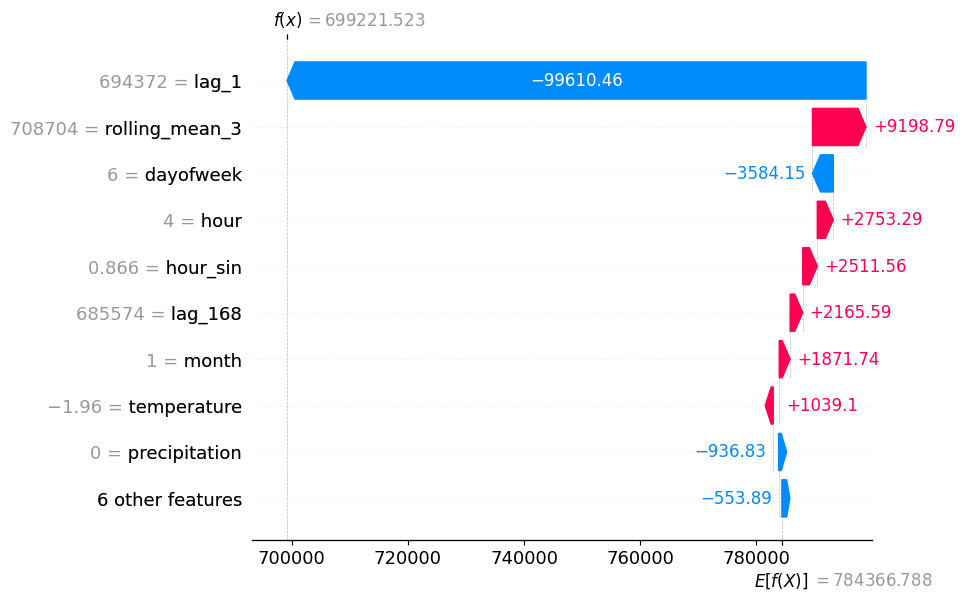

In [11]:
import shap
from xgboost import XGBRegressor

# JSON에서 불러올 때
model = XGBRegressor()
model.load_model("best2.json")

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_val)

# SHAP explainer 생성
explainer = shap.Explainer(model, X_train)

# 예측값에 대한 SHAP 값 계산
shap_values = explainer(X_val)

# 전체 피처 중요도 시각화
shap.plots.beeswarm(shap_values)

# 개별 시점 예측 설명 (예: 100번째 시점)
shap.plots.waterfall(shap_values[100])

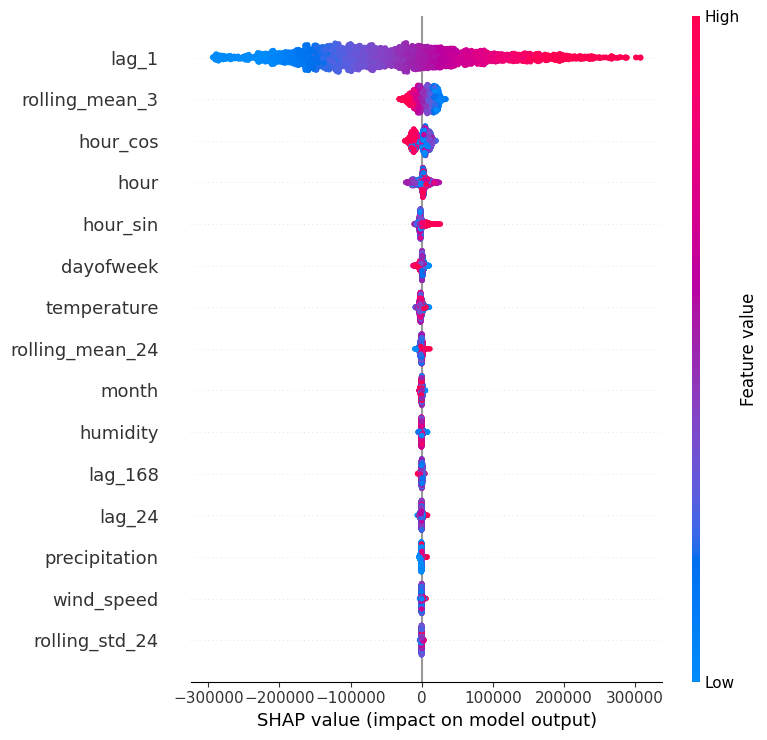

In [12]:
shap.summary_plot(shap_values, X_val)